In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential, layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
df = pd.read_csv('ecommerceDataset.csv', header = None)

In [29]:
df = df.sample(frac = 1) 

In [30]:
df.reset_index(drop = True, inplace = True)

In [31]:
df = df[0:1000]

In [32]:
df.columns

Index([0, 1], dtype='int64')

In [33]:
df.head()

,0,1
0,Books,Hank Haney's Essentials of the Swing: A 7-Poin...
1,Books,Environment
2,Household,"L'Oreal Paris Base Magique Primer, 15ml Base M..."
3,Electronics,boAt Rockerz 255 Sports Bluetooth Wireless Ear...
4,Household,Premier Stainless Steel Milk Boiler (1.5 Litre...


In [34]:
df.tail()

,0,1
995,Electronics,CrossBeats PULSE IPX5 Bluetooth In-Ear Sports ...
996,Household,HealthSense Chef-Mate KS 50 Digital Kitchen Sc...
997,Electronics,"The Crossover Review ""This novel in verse is r..."
998,Books,Intermediate English Grammar Supplementary Exe...
999,Books,The Theory of Everything: The Origin and Fate ...


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   1       1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [36]:
df.isna().sum()

0    0
1    0
dtype: int64

In [37]:
df.shape

(1000, 2)

In [38]:
df.dtypes

0    object
1    object
dtype: object

In [39]:
df.duplicated().sum()

np.int64(10)

In [46]:
df.dropna(inplace = True)

In [47]:
for i in range(6):
    print(df[0][i],'--',df[1][i])
    print()

Books -- Hank Haney's Essentials of the Swing: A 7-Point Plan for Building a Better Swing and Shaping Your Shots 

Books -- Environment 

Household -- L'Oreal Paris Base Magique Primer, 15ml Base Magique transforming smoothing primer instantly smoothes pores and creates an even surface for a flawless make-up result that lasts.

Electronics -- boAt Rockerz 255 Sports Bluetooth Wireless Earphone with Immersive Stereo Sound and Hands Free Mic (Raging Red) Colour:Raging Red   Have you ditched the 3.5mm headphones jack and now looking for a good pair of Bluetooth Earphones to go wireless? Well look no further. You may wonder where we put it, but it is all there: The new Rockerz 255 are equipped with the latest Bluetooth 4.1-CSR8635 chipset and 10mm drivers. Together they ensure crystal clear wireless transmission in true HD sound. Redefine your style statement with bright Neon green and black blend of the rockerz 255. With its 6 hours play time, you're sure to spend a quarter of your day wi

In [42]:
df.drop_duplicates(inplace=True)
print(df.shape)

(990, 2)


In [48]:
for i in range(5):
    print(df[0][i],'--',df[1][i])
    print()

Books -- Hank Haney's Essentials of the Swing: A 7-Point Plan for Building a Better Swing and Shaping Your Shots 

Books -- Environment 

Household -- L'Oreal Paris Base Magique Primer, 15ml Base Magique transforming smoothing primer instantly smoothes pores and creates an even surface for a flawless make-up result that lasts.

Electronics -- boAt Rockerz 255 Sports Bluetooth Wireless Earphone with Immersive Stereo Sound and Hands Free Mic (Raging Red) Colour:Raging Red   Have you ditched the 3.5mm headphones jack and now looking for a good pair of Bluetooth Earphones to go wireless? Well look no further. You may wonder where we put it, but it is all there: The new Rockerz 255 are equipped with the latest Bluetooth 4.1-CSR8635 chipset and 10mm drivers. Together they ensure crystal clear wireless transmission in true HD sound. Redefine your style statement with bright Neon green and black blend of the rockerz 255. With its 6 hours play time, you're sure to spend a quarter of your day wi

In [49]:
print(df[0].unique())

['Books' 'Household' 'Electronics' 'Clothing & Accessories']


In [51]:
def preprocess(sentence):
    sentence = sentence.lower()
    text = re.sub(r"[^a-zA-Z0-9]", ' ', sentence).split()
    lemma = WordNetLemmatizer()
    text = [lemma.lemmatize(i) for i in text]
    return ' '.join(text)

In [52]:
df[1] = df[1].apply(preprocess)

In [54]:
for i in range(6):
    print(df[0][i],'--',df[1][i])
    print()

Books -- hank haney s essential of the swing a 7 point plan for building a better swing and shaping your shot

Books -- environment

Household -- l oreal paris base magique primer 15ml base magique transforming smoothing primer instantly smoothes pore and creates an even surface for a flawless make up result that last

Electronics -- boat rockerz 255 sport bluetooth wireless earphone with immersive stereo sound and hand free mic raging red colour raging red have you ditched the 3 5mm headphone jack and now looking for a good pair of bluetooth earphone to go wireless well look no further you may wonder where we put it but it is all there the new rockerz 255 are equipped with the latest bluetooth 4 1 csr8635 chipset and 10mm driver together they ensure crystal clear wireless transmission in true hd sound redefine your style statement with bright neon green and black blend of the rockerz 255 with it 6 hour play time you re sure to spend a quarter of your day with these earphone listen to 

C:\Users\user\AppData\Local\Temp\ipykernel_19516\3822832016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y = df[0], palette=['purple','blue','orange','yellow'])


<Axes: ylabel='count'>

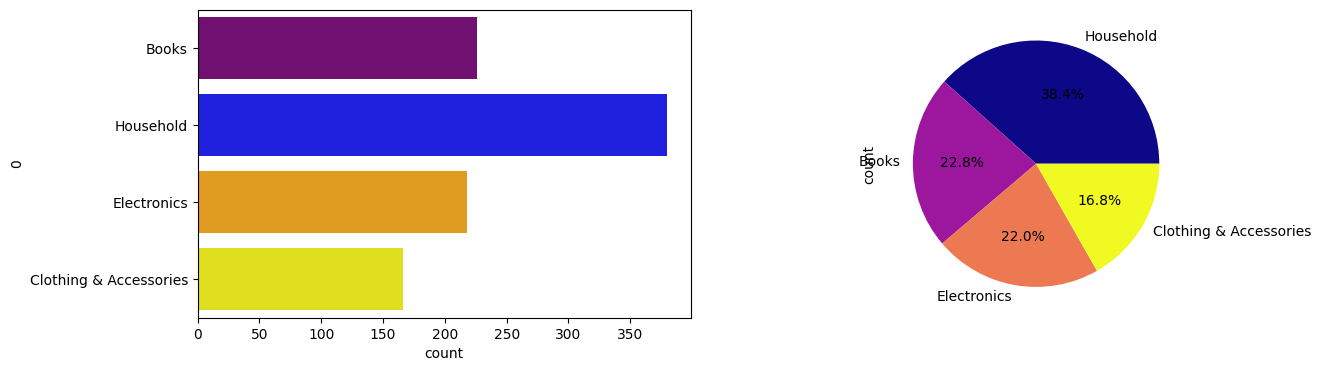

In [57]:
plt.figure(figsize= (14,4))
plt.subplot(1,2,1)
sns.countplot(y = df[0], palette=['purple','blue','orange','yellow'])
plt.subplot(1,2,2)
df[0].value_counts().plot.pie(autopct = '%1.1f%%', cmap = 'plasma')

In [58]:
X = df[1]

In [59]:
y=df[0]

In [60]:
y = y.map({'Household':0,'Books':1, 'Clothing & Accessories':2, 'Electronics':3}) 

In [61]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)
vocab_size = len(tokenizer.word_index) + 1
def text_encoding(txt):
    encoded_docs = tokenizer.texts_to_sequences(txt)
    padded_sequence = pad_sequences(encoded_docs, maxlen = 128)
    return padded_sequence
X = text_encoding(X)

In [62]:
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2)

In [64]:
model = Sequential()

model.add(layers.Embedding(vocab_size, 128))

model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=True)))
model.add(layers.Dropout(0.2))

model.add(layers.Bidirectional(layers.LSTM(128)))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(4, activation = 'sigmoid'))

In [65]:
model.compile(optimizer = 'adam', loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [66]:
model.fit(X_train, y_train, epochs = 10, validation_split=0.05)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 51s 400ms/step - accuracy: 0.4069 - loss: 1.2947 - val_accuracy: 0.4250 - val_loss: 1.1459
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.6064 - loss: 0.9503 - val_accuracy: 0.5500 - val_loss: 0.9999
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.8311 - loss: 0.5274 - val_accuracy: 0.7500 - val_loss: 0.6239
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.9056 - loss: 0.3286 - val_accuracy: 0.7250 - val_loss: 0.7809
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.9229 - loss: 0.2372 - val_accuracy: 0.7000 - val_loss: 0.7306
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step - accuracy: 0.9734 - loss: 0.0870 - val_accuracy: 0.8000 - val_loss: 0.7557
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.9521 - loss: 0.1536 - val_accuracy: 0.7750 - val_loss: 0.5362
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.9707 - loss: 0.0957 - val_accuracy: 0

In [67]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step


In [68]:
y_pred = [np.argmax(i) for i in y_pred]

In [69]:
accuracy_score(y_test,y_pred)

0.8232323232323232

<Axes: >

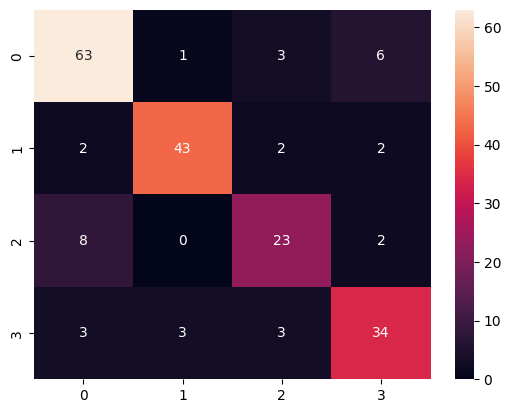

In [70]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt = 'd')